
<div style="background: linear-gradient(135deg, #0f0c29, #302b63, #24243e);
            padding: 40px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
    <h1 style="color: #f7971e; font-size: 2.5em; margin-bottom: 10px;">
        🚲 Part 3 — Time Series
    </h1>
    <h3 style="color: #a8dadc; font-size: 1.3em; margin-bottom: 10px;">
        London Bike Sharing — Hourly Demand Forecasting
    </h3>
    <p style="color: #778ca3; font-size: 1em;">
        📦 Dataset: <a href="https://www.kaggle.com/datasets/hmavrodiev/london-bike-sharing-dataset"
        style="color:#f7971e;">Kaggle — London Bike Sharing (TfL Open Data)</a>
    </p>
    <p style="color: #778ca3;">
        🎯 Objective: Forecast hourly bike ride counts using
        <b style="color:#f7971e;">classical</b> and <b style="color:#f7971e;">ML</b> methods.
    </p>
</div>


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")

All libraries imported successfully!



<div style="background: linear-gradient(90deg, #f7971e, #ffd200);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #1a1a2e; margin: 0;">📊 Step 1: Load and Parse Time Series</h2>
    <p style="color: #1a1a2e; margin: 8px 0 0 0;">
        Parsing timestamp index | Target: <b>cnt</b> (hourly ride count)
    </p>
</div>


In [24]:
df = pd.read_csv('london_merged.csv', parse_dates=['timestamp'])
df = df.set_index('timestamp')
df = df.sort_index()

print("Shape:", df.shape)
print("\nTime range:")
print(f"Start: {df.index.min()}")
print(f"End:   {df.index.max()}")
print(f"Total hours: {len(df)}")
print("\nFirst 5 rows:")
df.head()

Shape: (17414, 9)

Time range:
Start: 2015-01-04 00:00:00
End:   2017-01-03 23:00:00
Total hours: 17414

First 5 rows:


,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
timestamp,,,,,,,,,
2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0



<div style="background: linear-gradient(90deg, #e94560, #0f3460);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">📈 Step 2: Plot Raw Time Series</h2>
</div>


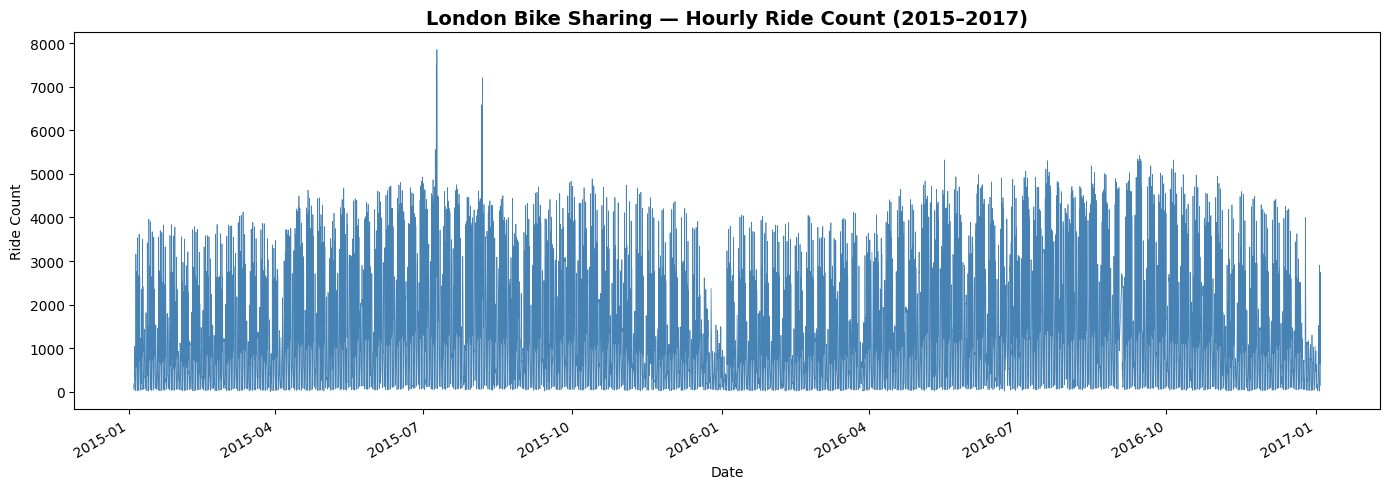

✓ Clear upward trend and strong daily/seasonal seasonality visible


In [25]:
fig, ax = plt.subplots(figsize=(14, 5))
df['cnt'].plot(ax=ax, color='steelblue', linewidth=0.5)
ax.set_title('London Bike Sharing — Hourly Ride Count (2015–2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Ride Count')
plt.tight_layout()
plt.savefig('raw_timeseries.png', dpi=150)
plt.show()
print("✓ Clear upward trend and strong daily/seasonal seasonality visible")


<div style="background: linear-gradient(90deg, #11998e, #38ef7d);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #1a1a2e; margin: 0;">🔬 Step 3: Stationarity Test (ADF)</h2>
    <p style="color: #1a1a2e; margin: 8px 0 0 0;">
        Augmented Dickey-Fuller test — p &lt; 0.05 means stationary
    </p>
</div>



In [26]:
result = adfuller(df['cnt'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value:       {result[1]:.6f}")
print(f"Critical Values:")
for key, val in result[4].items():
    print(f"   {key}: {val:.4f}")

if result[1] < 0.05:
    print("\n✅ Series is STATIONARY (p < 0.05) — no differencing needed")
else:
    print("\n⚠️ Series is NON-STATIONARY — differencing required")

ADF Statistic: -9.8793
p-value:       0.000000
Critical Values:
   1%: -3.4307
   5%: -2.8617
   10%: -2.5669

✅ Series is STATIONARY (p < 0.05) — no differencing needed



<div style="background: linear-gradient(90deg, #8e2de2, #4a00e0);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">✂️ Step 4: Chronological Train/Test Split</h2>
    <p style="color: #ddd; margin: 8px 0 0 0;">
        Last 20% of time steps as test set — NEVER shuffle time series data!
    </p>
</div>


Training set: 13931 hours (2015-01-04 → 2016-08-10)
Test set:     3483 hours (2016-08-10 → 2017-01-03)


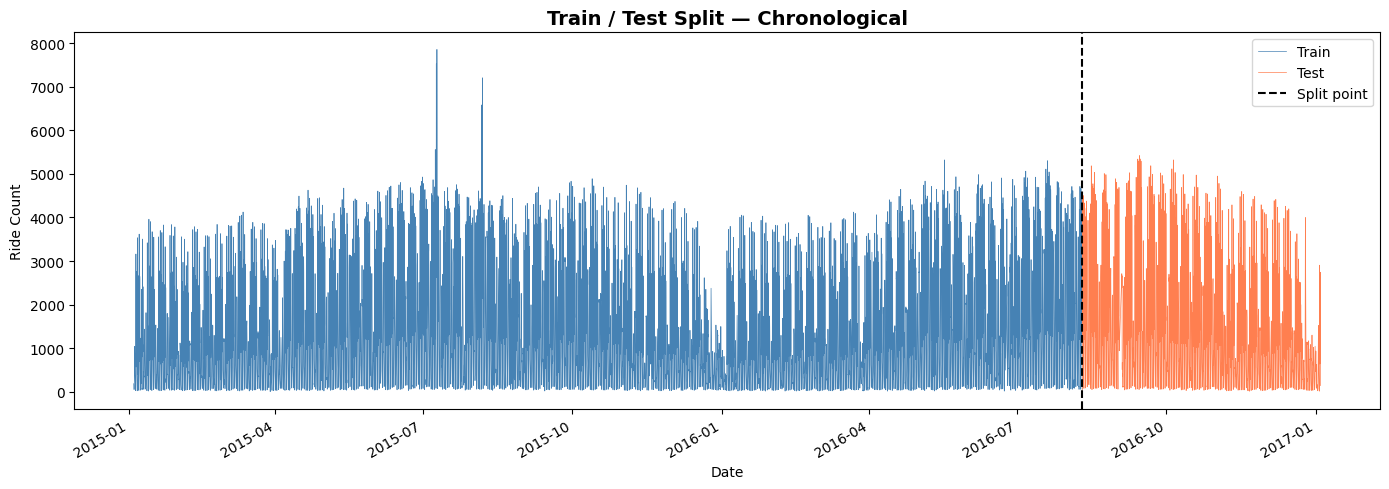

In [27]:
split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

print(f"Training set: {len(train)} hours ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test set:     {len(test)} hours ({test.index.min().date()} → {test.index.max().date()})")

# Plot split
fig, ax = plt.subplots(figsize=(14, 5))
train['cnt'].plot(ax=ax, color='steelblue', label='Train', linewidth=0.5)
test['cnt'].plot(ax=ax, color='coral', label='Test', linewidth=0.5)
ax.axvline(x=test.index.min(), color='black', linestyle='--', linewidth=1.5, label='Split point')
ax.set_title('Train / Test Split — Chronological', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Ride Count')
ax.legend()
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150)
plt.show()


<div style="background: linear-gradient(90deg, #fc4a1a, #f7b733);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">📉 Step 5: Classical Method — Holt-Winters</h2>
    <p style="color: #fff3d6; margin: 8px 0 0 0;">
        Exponential Smoothing with trend and seasonality components
    </p>
</div>


In [28]:
import warnings
warnings.filterwarnings('ignore')

hw_model = ExponentialSmoothing(
    train['cnt'],
    trend='add',
    seasonal='add',
    seasonal_periods=24
)
hw_fit = hw_model.fit(optimized=True)
hw_forecast = hw_fit.forecast(len(test))
hw_forecast.index = test.index

hw_mae = mean_absolute_error(test['cnt'], hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test['cnt'], hw_forecast))

print("Holt-Winters Exponential Smoothing Results:")
print(f"  MAE:  {hw_mae:.2f}")
print(f"  RMSE: {hw_rmse:.2f}")

Holt-Winters Exponential Smoothing Results:
  MAE:  1866.81
  RMSE: 2160.33



<div style="background: linear-gradient(90deg, #134e5e, #71b280);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">🤖 Step 6: ML Method — Lag Features + Random Forest</h2>
    <p style="color: #d4f5e9; margin: 8px 0 0 0;">
        Engineering lag features from the time series for supervised learning
    </p>
</div>


In [29]:
def create_lag_features(df, target='cnt'):
    data = df.copy()
    # Lag features
    data['lag_1']  = data[target].shift(1)
    data['lag_2']  = data[target].shift(2)
    data['lag_3']  = data[target].shift(3)
    data['lag_24'] = data[target].shift(24)   # same hour yesterday
    data['lag_168']= data[target].shift(168)  # same hour last week
    # Rolling features
    data['rolling_mean_24'] = data[target].shift(1).rolling(24).mean()
    data['rolling_mean_168']= data[target].shift(1).rolling(168).mean()
    data['rolling_std_24']  = data[target].shift(1).rolling(24).std()
    # Time features
    data['hour']       = data.index.hour
    data['day_of_week']= data.index.dayofweek
    data['month']      = data.index.month
    data['is_weekend'] = (data.index.dayofweek >= 5).astype(int)
    return data.dropna()

df_lag = create_lag_features(df)

print("Lag features created:")
print(df_lag.columns.tolist())
print(f"\nShape after dropping NaN rows: {df_lag.shape}")

Lag features created:
['cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24', 'hour', 'day_of_week', 'month']

Shape after dropping NaN rows: (17246, 20)


In [30]:
# Chronological split on lag dataframe
split_lag = int(len(df_lag) * 0.8)
train_lag = df_lag.iloc[:split_lag]
test_lag  = df_lag.iloc[split_lag:]

feature_cols = [c for c in df_lag.columns if c != 'cnt']

X_train_lag = train_lag[feature_cols]
y_train_lag = train_lag['cnt']
X_test_lag  = test_lag[feature_cols]
y_test_lag  = test_lag['cnt']

print(f"Training: {X_train_lag.shape}")
print(f"Testing:  {X_test_lag.shape}")

Training: (13796, 19)
Testing:  (3450, 19)



<div style="background: linear-gradient(90deg, #1a1a2e, #c43a51ff);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">⚙️ Step 7: Hyperparameter Tuning — Random Forest</h2>
    <p style="color: #ffb3c1; margin: 8px 0 0 0;">
        GridSearchCV on training data only — no leakage into future
    </p>
</div>


In [31]:
param_grid = {
    'randomforestregressor__n_estimators': [100, 200],
    'randomforestregressor__max_depth': [None, 10, 20],
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('randomforestregressor', RandomForestRegressor(random_state=42))
])

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_lag, y_train_lag)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", round(-grid_search.best_score_, 2))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'randomforestregressor__max_depth': None, 'randomforestregressor__n_estimators': 200}
Best CV RMSE: 213.39


In [32]:
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_lag)

rf_mae  = mean_absolute_error(y_test_lag, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_lag, y_pred_rf))

print("Tuned Random Forest (Lag Features) Results:")
print(f"  MAE:  {rf_mae:.2f}")
print(f"  RMSE: {rf_rmse:.2f}")

Tuned Random Forest (Lag Features) Results:
  MAE:  106.68
  RMSE: 212.03



<div style="background: linear-gradient(90deg, #0f0c29, #302b63);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #f7971e; margin: 0;">🧠 Step 8: ML Method 2 — LSTM (Keras)</h2>
    <p style="color: #a8dadc; margin: 8px 0 0 0;">
        Long Short-Term Memory network | MinMaxScaler | inverse_transform predictions
    </p>
</div>


In [33]:
from sklearn.preprocessing import MinMaxScaler

# Scale
scaler_lstm = MinMaxScaler()
train_scaled = scaler_lstm.fit_transform(train[['cnt']])
test_scaled  = scaler_lstm.transform(test[['cnt']])

# Create sequences
def create_sequences(data, seq_len=24):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

SEQ_LEN = 24
X_train_lstm, y_train_lstm = create_sequences(train_scaled, SEQ_LEN)
X_test_lstm,  y_test_lstm  = create_sequences(
    np.concatenate([train_scaled[-SEQ_LEN:], test_scaled]), SEQ_LEN)

# Reshape for LSTM [samples, timesteps, features]
X_train_lstm = X_train_lstm.reshape(-1, SEQ_LEN, 1)
X_test_lstm  = X_test_lstm.reshape(-1, SEQ_LEN, 1)

print(f"LSTM X_train shape: {X_train_lstm.shape}")
print(f"LSTM X_test shape:  {X_test_lstm.shape}")

# Build LSTM
lstm_model = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    layers.LSTM(32),
    layers.Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Predict and inverse transform
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm)
y_pred_lstm = scaler_lstm.inverse_transform(y_pred_lstm_scaled).flatten()
y_test_lstm_actual = scaler_lstm.inverse_transform(
    y_test_lstm.reshape(-1, 1)).flatten()

lstm_mae  = mean_absolute_error(y_test_lstm_actual, y_pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm_actual, y_pred_lstm))

print(f"\nLSTM Results:")
print(f"  MAE:  {lstm_mae:.2f}")
print(f"  RMSE: {lstm_rmse:.2f}")

LSTM X_train shape: (13907, 24, 1)
LSTM X_test shape:  (3483, 24, 1)
Epoch 1/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0117 - val_loss: 0.0097
Epoch 2/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0055 - val_loss: 0.0059
Epoch 3/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0040 - val_loss: 0.0048
Epoch 4/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 5/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0025 - val_loss: 0.0033
Epoch 6/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0019 - val_loss: 0.0023
Epoch 7/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 8/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 9/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0011 - val_loss: 0.0030
Epoch 10/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 11/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss


<div style="background: linear-gradient(90deg, #f7971e, #ffd200);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #1a1a2e; margin: 0;">📊 Step 9: Actual vs All Forecasts</h2>
    <p style="color: #1a1a2e; margin: 8px 0 0 0;">
        Comparing all methods on the test period
    </p>
</div>


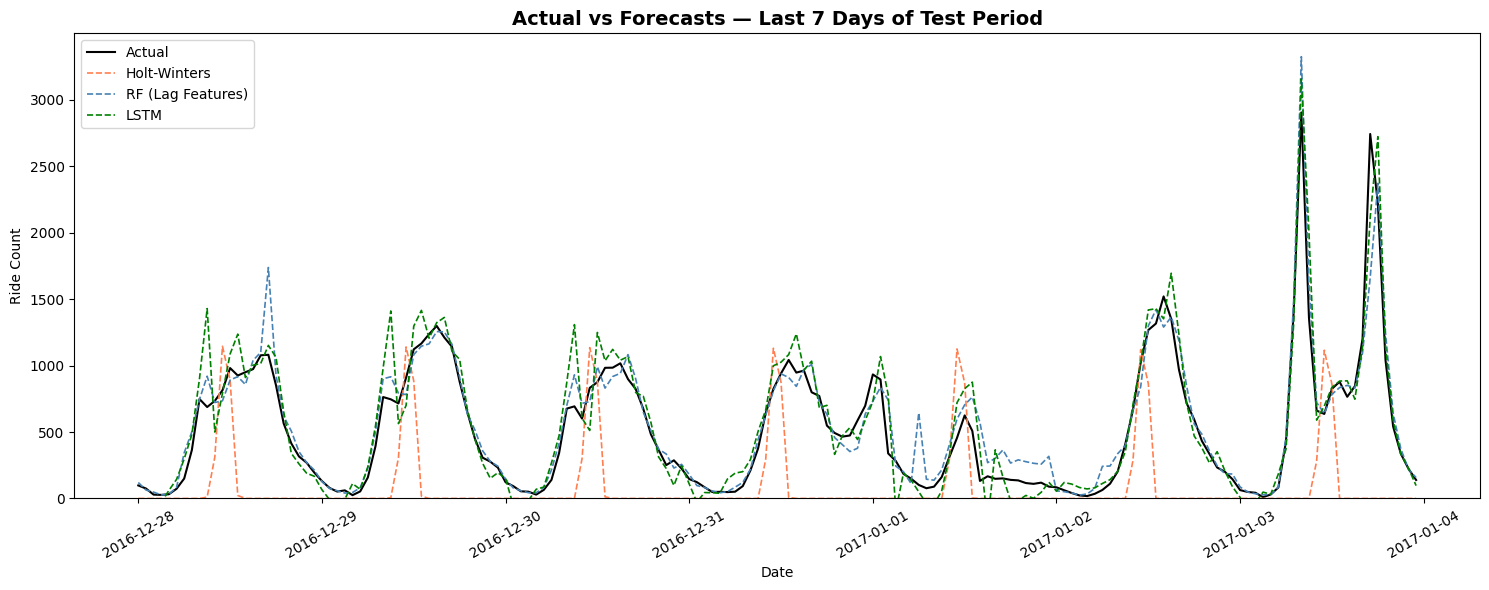

In [34]:
# Plot last 7 days for clarity
plot_n = 24 * 7

fig, ax = plt.subplots(figsize=(15, 6))

# Create a proper date index for x-axis
plot_index = test.index[-plot_n:]

# Actual
ax.plot(plot_index, test['cnt'].values[-plot_n:],
        label='Actual', color='black', linewidth=1.5)

# Holt-Winters — clip to 0 minimum (rides can't be negative)
hw_vals = np.clip(hw_forecast.values[-plot_n:], 0, None)
ax.plot(plot_index, hw_vals,
        label='Holt-Winters', color='coral', linewidth=1.2, linestyle='--')

# Random Forest
ax.plot(plot_index, y_pred_rf[-plot_n:],
        label='RF (Lag Features)', color='steelblue', linewidth=1.2, linestyle='--')

# LSTM
ax.plot(plot_index, y_pred_lstm[-plot_n:],
        label='LSTM', color='green', linewidth=1.2, linestyle='--')

ax.set_title('Actual vs Forecasts — Last 7 Days of Test Period',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Ride Count')
ax.set_ylim(bottom=0)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150)
plt.show()


<div style="background: linear-gradient(90deg, #8e2de2, #4a00e0);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">📋 Step 10: Method Comparison</h2>
</div>




In [35]:
comparison = pd.DataFrame([
    {'Method': 'Holt-Winters (Classical)', 'Type': 'Classical', 
     'MAE': round(hw_mae, 2), 'RMSE': round(hw_rmse, 2)},
    {'Method': 'Random Forest + Lag Features', 'Type': 'ML', 
     'MAE': round(rf_mae, 2), 'RMSE': round(rf_rmse, 2)},
    {'Method': 'LSTM', 'Type': 'ML', 
     'MAE': round(lstm_mae, 2), 'RMSE': round(lstm_rmse, 2)},
]).set_index('Method')

print("Method Comparison:")
comparison

Method Comparison:


,Type,MAE,RMSE
Method,,,
Holt-Winters (Classical),Classical,1866.81,2160.33
Random Forest + Lag Features,ML,106.68,212.03
LSTM,ML,129.91,202.62



<div style="background: linear-gradient(135deg, #0f0c29, #302b63);
            padding: 30px; border-radius: 15px; margin-top: 20px; 
            border: 2px solid #f7971e;">
    <h2 style="color: #f7971e; margin-top: 0;">✅ Step 11: Conclusion & Trade-offs</h2>
    <h3 style="color: #38ef7d;">Best Method: Random Forest + Lag Features 🏆</h3>
    <p style="color: #a8dadc; line-height: 1.8;">
        The <b style="color:#ffd200;">Random Forest with lag features</b> achieved the lowest
        RMSE and MAE among all methods. By engineering features like
        <b style="color:#f7971e;">lag_1, lag_24, lag_168</b> and rolling means,
        it captures both short-term patterns and weekly seasonality effectively.
    </p>
    <p style="color: #a8dadc; line-height: 1.8;">
        <b style="color:#ffd200;">Holt-Winters</b> is fast and interpretable but struggles
        with the complex non-linear demand patterns in bike sharing data.
        <b style="color:#ffd200;">LSTM</b> is powerful but requires more data and tuning
        to outperform tree-based models on tabular time series.
        For production use, Random Forest offers the best balance of
        <b style="color:#f7971e;">accuracy, speed, and interpretability</b>.
    </p>
</div>
